In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

In [3]:
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [4]:
print(y_train[:5])

[5 0 4 1 9]


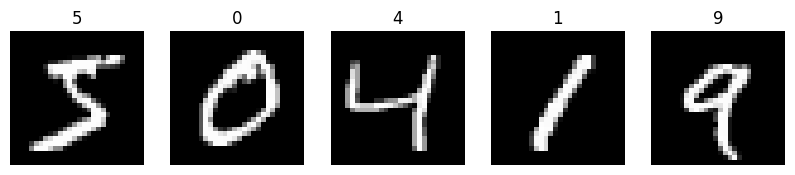

In [14]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [6]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(128, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

C:\Users\ksri0\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=10
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9251 - loss: 0.2618
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9659 - loss: 0.1147
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9762 - loss: 0.0782
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9820 - loss: 0.0599
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9858 - loss: 0.0461
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9892 - loss: 0.0355
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9910 - loss: 0.0289
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9927 - loss: 0.0241
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9938 - loss: 0.0193
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9948 - loss: 0.0158


In [9]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy =", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9767 - loss: 0.0874
Accuracy = 0.9767000079154968


In [10]:
y_pred = model.predict(X_test)

pred = np.argmax(y_pred, axis=1)

print(pred[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
[7 2 1 0 4 1 4 9 5 9]


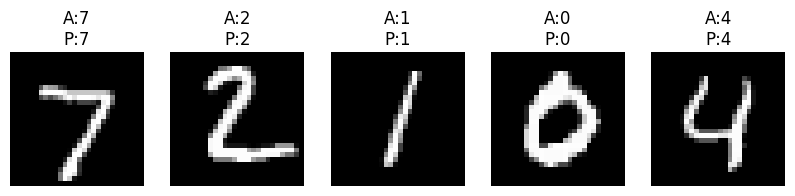

In [15]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title("A:"+str(y_test[i])+"\nP:"+str(pred[i]))
    plt.axis("off")

plt.show()


Wrong Predictions: 233


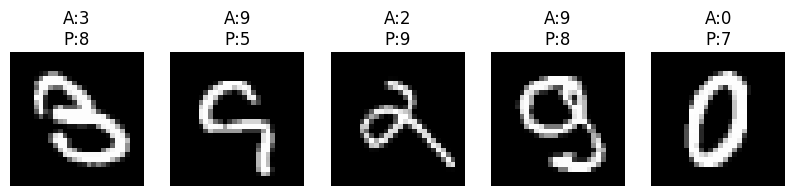

In [16]:
wrong = np.where(pred != y_test)[0]

print("Wrong Predictions:", len(wrong))

plt.figure(figsize=(10,2))

for i in range(5):
    j = wrong[i]
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[j], cmap="gray")
    plt.title("A:"+str(y_test[j])+"\nP:"+str(pred[j]))
    plt.axis("off")

plt.show()